# TP2 - Doublons et Standardisation

**Difficulté:** Débutant  
**Dataset:** customers_duplicates.csv  
**Description:** Détection et suppression des doublons, standardisation des formats

---


## Imports des Bibliothèques


In [3]:
!pip install pandas
!pip install seaborn
!pip install numpy
!pip install matplotlib
!pip install missingno

In [4]:
# Bibliothèques de base
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# Configuration des graphiques
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Ignorer les warnings
import warnings
warnings.filterwarnings('ignore')

# Affichage pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

print(" Bibliothèques importées avec succès!")

 Bibliothèques importées avec succès!


## Import du Dataset


In [5]:
# Charger le dataset
df = pd.read_csv(r'C:\Users\Utilisateur\Desktop\e-commerce\Pipeline-ETL---Ingestion-transformation-et-chargement-de-donn-es-multi-sources\data\customers_duplicates.csv')

# Afficher les informations de base
print(f"📏 Dimensions: {df.shape[0]} lignes × {df.shape[1]} colonnes")
print(f"Taille mémoire: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print("\n" + "="*80 + "\n")

# Aperçu des données
display(df.head())
print("\n" + "="*80 + "\n")

# Informations sur les colonnes
df.info()

📏 Dimensions: 12 lignes × 5 colonnes
Taille mémoire: 0.00 MB




,name,email,phone,gender,country
0,Bob Dubois,ALICE.MARTIN@GMAIL.COM,+33623456789,Male,Belgique
1,alice martin,bob.dubois@yahoo.fr,+33623456789,Male,Belgique
2,Bob Dubois,bob.dubois@yahoo.fr,+33 6 12 34 56 78,Male,Belgique
3,David Bernard,david.bernard@company.com,+33645678901,F,Suisse
4,Claire Petit,claire.petit@outlook.com,+33634567890,Female,FR




<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   name     12 non-null     str  
 1   email    12 non-null     str  
 2   phone    12 non-null     str  
 3   gender   12 non-null     str  
 4   country  12 non-null     str  
dtypes: str(5)
memory usage: 1.3 KB


## Visualisation des Valeurs Manquantes


<Figure size 1400x800 with 0 Axes>

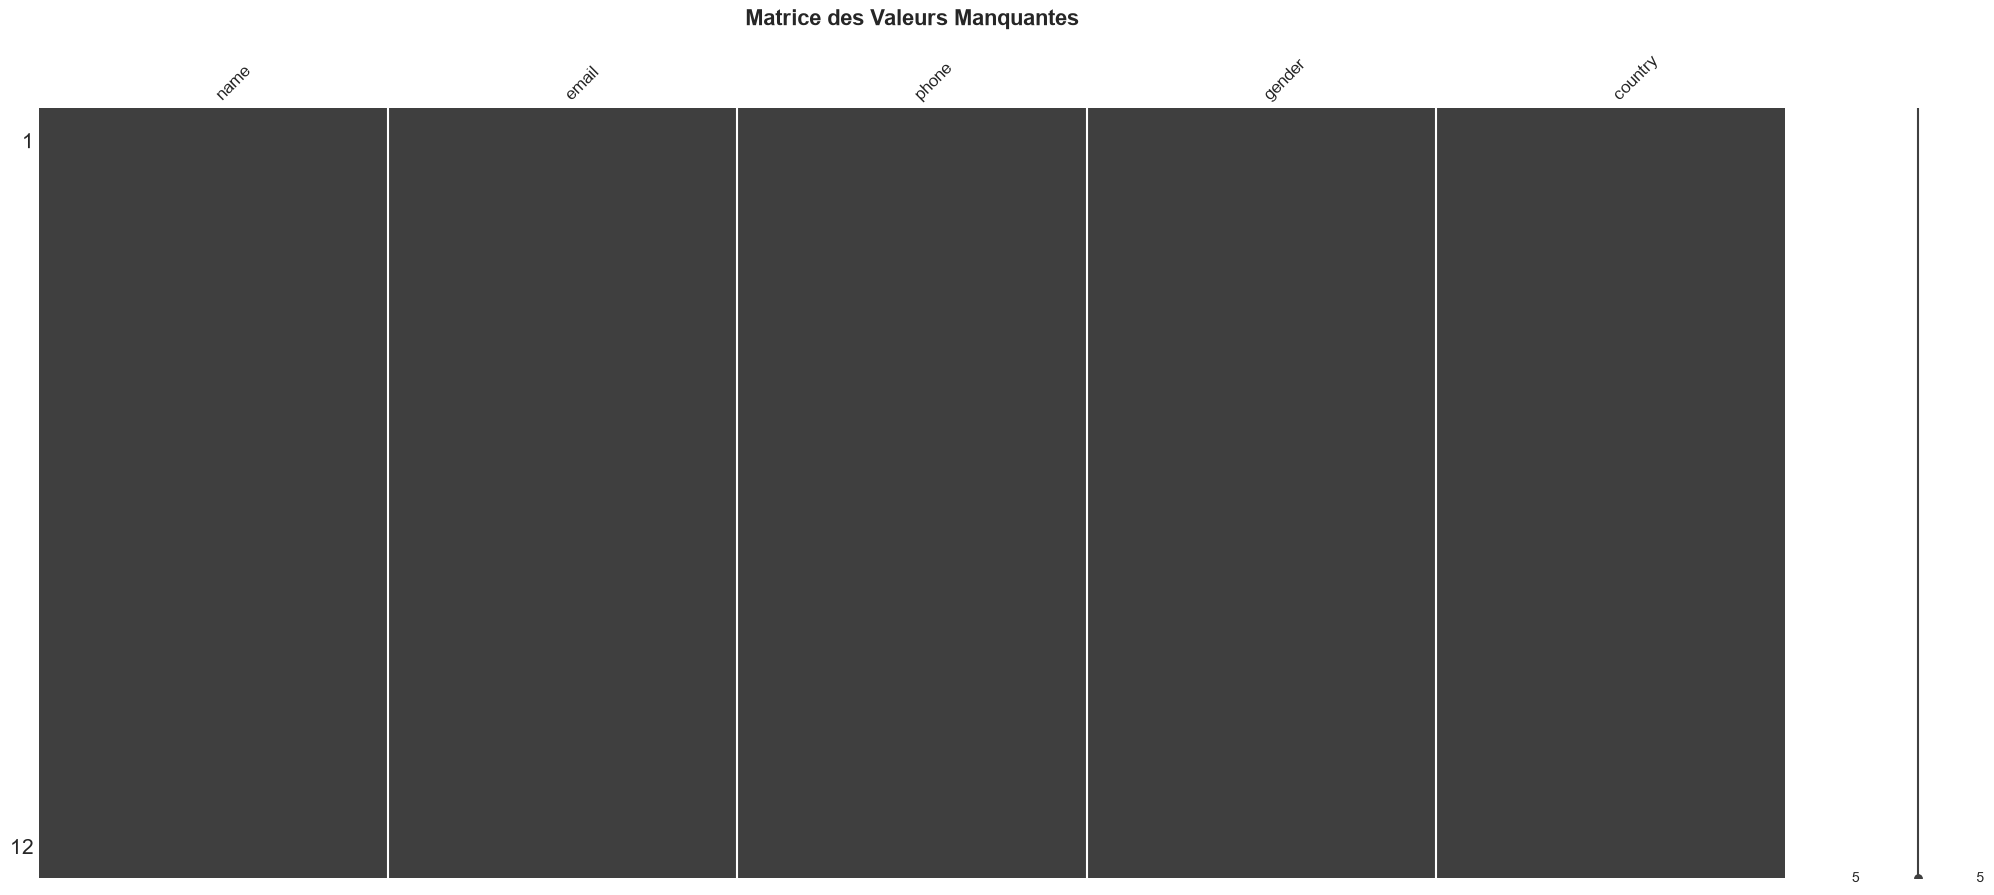


 Statistiques des Valeurs Manquantes:



,Nombre_Missing,Pourcentage_Missing


In [6]:
# Matrice de visualisation des valeurs manquantes
plt.figure(figsize=(14, 8))
msno.matrix(df, fontsize=12, sparkline=True)
plt.title("Matrice des Valeurs Manquantes", fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Statistiques des valeurs manquantes
missing_stats = pd.DataFrame({
    'Nombre_Missing': df.isnull().sum(),
    'Pourcentage_Missing': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Pourcentage_Missing', ascending=False)

print("\n Statistiques des Valeurs Manquantes:\n")
display(missing_stats[missing_stats['Nombre_Missing'] > 0])


## Questions Préalables

**Avant de commencer le TP, répondez aux questions suivantes en analysant le dataset:**

1. Combien de doublons exacts le dataset contient-il ?
2. Quelles colonnes peuvent servir de clés pour identifier les doublons ?
3. Y a-t-il des variations d'écriture dans les catégories (ex: 'M'/'Male') ?
4. Combien de formats de téléphone différents sont présents ?
5. Les emails sont-ils tous en minuscules ?
6. Y a-t-il des espaces en début ou fin de chaînes ?
7. Combien de clients uniques après déduplication ?
8. Quelle est la variation la plus fréquente du genre ?
9. Y a-t-il des doublons partiels (même nom mais email différent) ?
10. Quel pourcentage du dataset est constitué de doublons ?


In [7]:
# Cellule pour vos réponses et analyses
# Utilisez cette cellule pour explorer les données et répondre aux questions
1#.Combien de doublons exacts le dataset contient-il ?
print("Réponses aux questions:")
print("="*80)
# Écrivez vos réponses ici
# Identifier les doublons
duplicates = df.duplicated()

# Compter le nombre de lignes en trop (True = 1, False = 0)
print(f"Nombre de doublons: {duplicates.sum()}")

Réponses aux questions:
Nombre de doublons: 4


In [8]:
# Cellule pour vos réponses et analyses
# Utilisez cette cellule pour explorer les données et répondre aux questions
#2.Quelles colonnes peuvent servir de clés pour identifier les doublons ?

print("Réponses aux questions:")
print("="*80)

# Écrivez vos réponses ici
df.duplicated(subset=['name', 'phone'])

Réponses aux questions:


0     False
1     False
2     False
3     False
4     False
5     False
6      True
7      True
8      True
9      True
10     True
11     True
dtype: bool

In [9]:
# Cellule pour vos réponses et analyses
# Utilisez cette cellule pour explorer les données et répondre aux questions
#3.Y a-t-il des variations d'écriture dans les catégories (ex: 'M'/'Male') ?

print("Réponses aux questions:")
print("="*80)

# Écrivez vos réponses ici
# Voir toutes les valeurs uniques dans la colonne gender
print(df['gender'].unique())

# Ou voir combien de fois chaque valeur apparaît
print(df['gender'].value_counts())

Réponses aux questions:
<ArrowStringArray>
['Male', 'F', 'Female']
Length: 3, dtype: str
gender
Female    6
Male      5
F         1
Name: count, dtype: int64


In [10]:
# Cellule pour vos réponses et analyses
# Utilisez cette cellule pour explorer les données et répondre aux questions
#4.Combien de formats de téléphone différents sont présents ?

print("Réponses aux questions: Il y a 5 chaînes uniques, mais seulement 2 formats visuels : avec espaces et sans espaces")
print("="*80)

# Voir toutes les valeurs uniques de téléphone
print(df['phone'].unique())

# Ou voir combien de fois chaque format apparaît
print(df['phone'].value_counts())

Réponses aux questions: Il y a 5 chaînes uniques, mais seulement 2 formats visuels : avec espaces et sans espaces
<ArrowStringArray>
[     '+33623456789', '+33 6 12 34 56 78',      '+33645678901',
      '+33634567890',      '+33612345678']
Length: 5, dtype: str
phone
+33645678901         3
+33634567890         3
+33612345678         3
+33623456789         2
+33 6 12 34 56 78    1
Name: count, dtype: int64


In [11]:
# Cellule pour vos réponses et analyses
# Utilisez cette cellule pour explorer les données et répondre aux questions
#5.Les emails sont-ils tous en minuscules ?
print("Réponses aux questions:")
print("="*80)

# Écrivez vos réponses ici
# Voir toutes les emails

# Crée une variable et Compter les minuscule
email_minuscule = (df['email'] == df['email'].str.lower())
nb_minuscules = email_minuscule.sum()
#Crée une variable et Compter les majuscules
email_majuscules = (df['email'] != df['email'].str.lower())
nb_majuscules = email_majuscules.sum()

print(f"Emails en minuscules : {nb_minuscules}")
print(f"Emails avec majuscules : {nb_majuscules}")

Réponses aux questions:
Emails en minuscules : 11
Emails avec majuscules : 1


In [12]:
# Cellule pour vos réponses et analyses
# Utilisez cette cellule pour explorer les données et répondre aux questions
#6..Y a-t-il des espaces en début ou fin de chaînes ?
print("Réponses aux questions:")
print("="*80)
colonnes = df.select_dtypes(include="object").columns
for clo in colonnes :
    if (df[clo] != df[clo].str.strip()).any():
        print("il y a des espaces dans {clo}")
    else:
        print(f"pas d'espaces dans {clo}")
        

Réponses aux questions:
pas d'espaces dans name
pas d'espaces dans email
pas d'espaces dans phone
pas d'espaces dans gender
pas d'espaces dans country


In [13]:
# Cellule pour vos réponses et analyses
# Utilisez cette cellule pour explorer les données et répondre aux questions
#7 Combien de clients uniques après déduplication ?
print("Réponses aux questions:")
print("="*80)
email_minuscule = df['email'].str.lower()
email_minuscule
print(len(email_minuscule.unique()))

Réponses aux questions:
4


In [14]:
# Cellule pour vos réponses et analyses
# Utilisez cette cellule pour explorer les données et répondre aux questions
#8.Quelle est la variation la plus fréquente du genre ?
print("Réponses aux questions:")
print("="*80)
df["gender"].value_counts()
print(f"la fréquence la plus fréquente c'est : les femmes ")

Réponses aux questions:
la fréquence la plus fréquente c'est : les femmes 


In [15]:
# Cellule pour vos réponses et analyses
# Utilisez cette cellule pour explorer les données et répondre aux questions
#8.Quelle est la variation la plus fréquente du genre ?
print("Réponses aux questions:")
print("="*80)
df["gender"].value_counts()

Réponses aux questions:


gender
Female    6
Male      5
F         1
Name: count, dtype: int64

In [16]:
# Cellule pour vos réponses et analyses
# Utilisez cette cellule pour explorer les données et répondre aux questions
#9.Y a-t-il des doublons partiels (même nom mais email différent) ?
print("Réponses aux questions:")
print("="*80)
regroup = df.groupby(["name"])["email"].nunique()
regroup = regroup[regroup > 1]
regroup


Réponses aux questions:


name
Bob Dubois    2
Name: email, dtype: int64

In [17]:
# Cellule pour vos réponses et analyses
# Utilisez cette cellule pour explorer les données et répondre aux questions
#10Quel pourcentage du dataset est constitué de doublons ?
print("Réponses aux questions:")
print("="*80)
duplicates = df.duplicated().sum()
duplicates = (duplicates/df.shape[0] * 100).round(2)
duplicates



Réponses aux questions:


np.float64(33.33)

## Étapes du TP

**Suivez les étapes ci-dessous pour nettoyer le dataset:**

### Étape 1: Identifier et compter les doublons exacts
### Étape 2: Afficher quelques exemples de doublons
### Étape 3: Supprimer les doublons exacts en gardant la première occurrence
### Étape 4: Standardiser la casse (emails en minuscules, noms en title case)
### Étape 5: Supprimer les espaces en début/fin de toutes les colonnes texte
### Étape 6: Créer un mapping pour standardiser les catégories (genre, pays)
### Étape 7: Appliquer le mapping aux colonnes concernées
### Étape 8: Standardiser les formats de téléphone
### Étape 9: Vérifier les doublons restants après standardisation
### Étape 10: Créer un rapport de nettoyage avec les statistiques


In [18]:
# ========================================
# Étape 1: Identifier et compter les doublons exacts
# ========================================

# TODO: Écrivez votre code ici
duplicates = df.duplicated().sum()
duplicates


# Vérification
#print(f" Étape 1 complétée")

np.int64(4)

In [19]:
# ========================================
# Étape 2: Afficher quelques exemples de doublons
# ========================================

# TODO: Écrivez votre code ici
df.duplicated().head()
display(df[df.duplicated(keep = False)].head())


# Vérification
#print(f" Étape 2 complétée")

,name,email,phone,gender,country
5,Alice Martin,alice.martin@gmail.com,+33612345678,Female,France
6,David Bernard,david.bernard@company.com,+33645678901,Male,Suisse
7,David Bernard,david.bernard@company.com,+33645678901,Male,Suisse
8,Claire Petit,claire.petit@outlook.com,+33634567890,Female,France
9,Claire Petit,claire.petit@outlook.com,+33634567890,Female,France


In [20]:
# ========================================
# Étape 3: Supprimer les doublons exacts en gardant la première occurrence
# ========================================

# TODO: Écrivez votre code ici

supprimer_doublons  = df.duplicated().sum()
print(f"\n Vérification : {supprimer_doublons} doublons restants")

df = df.drop_duplicates(keep = "first")
doublons_apres = df.duplicated().sum()

if doublons_apres == 0:
    print("Tous les doublons ont été supprimés")
else:
    print(f"Attention : il reste {doublons_apres} doublons")
    
# Vérification
#print(f" Étape 3 complétée")


 Vérification : 4 doublons restants
Tous les doublons ont été supprimés


In [21]:
# ========================================
# Étape 4: Standardiser la casse (emails en minuscules, noms en title case)
# ========================================

# TODO: Écrivez votre code ici
df["email"] = df["email"].str.lower()
df["name"] = df["name"].str.title()
df.head(5)
# Vérification
#print(f" Étape 4 complétée")

,name,email,phone,gender,country
0,Bob Dubois,alice.martin@gmail.com,+33623456789,Male,Belgique
1,Alice Martin,bob.dubois@yahoo.fr,+33623456789,Male,Belgique
2,Bob Dubois,bob.dubois@yahoo.fr,+33 6 12 34 56 78,Male,Belgique
3,David Bernard,david.bernard@company.com,+33645678901,F,Suisse
4,Claire Petit,claire.petit@outlook.com,+33634567890,Female,FR


In [22]:
# ========================================
# Étape 5: Supprimer les espaces en début/fin de toutes les colonnes texte
# ========================================

# TODO: Écrivez votre code ici
colonnes = df.select_dtypes(include="object").columns
for clo in colonnes :
    df[clo] = df[clo].str.strip()
    print(f"les espaces sont supprimés dans : {clo}")

# Vérification
#print(f" Étape 5 complétée")

les espaces sont supprimés dans : name
les espaces sont supprimés dans : email
les espaces sont supprimés dans : phone
les espaces sont supprimés dans : gender
les espaces sont supprimés dans : country


In [23]:
# ========================================
# Étape 6: Créer un mapping pour standardiser les catégories (genre, pays)
# ========================================

# TODO: Écrivez votre code ici
category_mapping= {
    #genre
     'M': 'Male', 'H': 'Male', 'Homme': 'Male', 'homme': 'Male',
    'F': 'Female', 'Femme': 'Female', 'femme': 'Female',
    #pays
    'USA': 'United States', 'US': 'United States', 'Etats-Unis': 'United States',
    'UK': 'United Kingdom', 'GB': 'United Kingdom', 'FR' :'France'}

category_mapping
# Vérification
#print(f" Étape 6 complétée")

{'M': 'Male',
 'H': 'Male',
 'Homme': 'Male',
 'homme': 'Male',
 'F': 'Female',
 'Femme': 'Female',
 'femme': 'Female',
 'USA': 'United States',
 'US': 'United States',
 'Etats-Unis': 'United States',
 'UK': 'United Kingdom',
 'GB': 'United Kingdom',
 'FR': 'France'}

In [24]:
# ========================================
# Étape 7: Appliquer le mapping aux colonnes concernées
# ========================================

# TODO: Écrivez votre code ici
for col in ['gender', 'country']:
    if col in df.columns:
        df[col] = df[col].map(lambda x: category_mapping.get(x, x))
display(df)

# Vérification
#print(f" Étape 7 complétée")

,name,email,phone,gender,country
0,Bob Dubois,alice.martin@gmail.com,+33623456789,Male,Belgique
1,Alice Martin,bob.dubois@yahoo.fr,+33623456789,Male,Belgique
2,Bob Dubois,bob.dubois@yahoo.fr,+33 6 12 34 56 78,Male,Belgique
3,David Bernard,david.bernard@company.com,+33645678901,Female,Suisse
4,Claire Petit,claire.petit@outlook.com,+33634567890,Female,France
5,Alice Martin,alice.martin@gmail.com,+33612345678,Female,France
6,David Bernard,david.bernard@company.com,+33645678901,Male,Suisse
8,Claire Petit,claire.petit@outlook.com,+33634567890,Female,France


In [25]:
# ========================================
# Étape 8: Standardiser les formats de téléphone
# ========================================
import re
# TODO: Écrivez votre code ici
def standardize_phone(phone):
    """Standardise les numéros de téléphone au format international"""
    if pd.isna(phone):
        return None

    # Retirer tous les caractères non numériques
    phone = re.sub(r'\D', '', str(phone))

    # Format français
    if len(phone) == 10 and phone.startswith('0'):
        return f"+33{phone[1:]}"
    elif len(phone) == 9:  # Sans le 0 initial
        return f"+33{phone}"

    return f"+{phone}"

df['phone'] = df['phone'].apply(standardize_phone)
display(df['phone'])
# Vérification
#print(f" Étape 8 complétée")

0    +33623456789
1    +33623456789
2    +33612345678
3    +33645678901
4    +33634567890
5    +33612345678
6    +33645678901
8    +33634567890
Name: phone, dtype: str

In [26]:
# ========================================
# Étape 9: Vérifier les doublons restants après standardisation
# ========================================

# TODO: Écrivez votre code ici
df.duplicated().sum()
display(df[df.duplicated(keep = False)])
# Vérification
print(f" Étape 9 complétée")

,name,email,phone,gender,country
4,Claire Petit,claire.petit@outlook.com,+33634567890,Female,France
8,Claire Petit,claire.petit@outlook.com,+33634567890,Female,France


 Étape 9 complétée


In [27]:
# ========================================
# Étape 10: Créer un rapport de nettoyage avec les statistiques
# ========================================

# On connaît les dimensions de départ du TP2
lignes_initiales = 12
colonnes_initiales = 5

# Rapport de nettoyage basé sur ton DataFrame 'df' actuel
rapport = {
    'Dimensions_initiales': f"({lignes_initiales} lignes, {colonnes_initiales} colonnes)",
    'Dimensions_finales': f"({df.shape[0]} lignes, {df.shape[1]} colonnes)",
    'Lignes_supprimées': lignes_initiales - df.shape[0],
    'Colonnes_supprimées': 0,
    'Valeurs_manquantes_traitées': 0,  # Déjà traité dans le TP1
    'Doublons_supprimés': lignes_initiales - df.shape[0], 
    'Outliers_traités': 0,
    'Transformations_appliquées': [
        "1. Suppression des doublons exacts initiaux (keep='first')",
        "2. Standardisation de la casse (emails en minuscules, noms en Title Case)",
        "3. Suppression des espaces en début/fin de chaîne (.str.strip)",
        "4. Mapping des catégories (gender: F->Female, country: FR->France)",
        "5. Standardisation des numéros de téléphone via Regex (re.sub)",
        "6. Suppression finale des doublons révélés après la standardisation"
    ]
}

# Affichage du rapport
print("=" * 80)
print(" " * 25 + " RAPPORT DE NETTOYAGE (TP2)")
print("=" * 80)

for key, value in rapport.items():
    # L'astuce {key:.<40} aligne le texte à gauche sur 40 caractères avec des points
    print(f"{key:.<40} {value}")

print("=" * 80)
print("\n TP2 : Doublons et Standardisation terminé avec succès !")
print("=" * 80)

                          RAPPORT DE NETTOYAGE (TP2)
Dimensions_initiales.................... (12 lignes, 5 colonnes)
Dimensions_finales...................... (8 lignes, 5 colonnes)
Lignes_supprimées....................... 4
Colonnes_supprimées..................... 0
Valeurs_manquantes_traitées............. 0
Doublons_supprimés...................... 4
Outliers_traités........................ 0
Transformations_appliquées.............. ["1. Suppression des doublons exacts initiaux (keep='first')", '2. Standardisation de la casse (emails en minuscules, noms en Title Case)', '3. Suppression des espaces en début/fin de chaîne (.str.strip)', '4. Mapping des catégories (gender: F->Female, country: FR->France)', '5. Standardisation des numéros de téléphone via Regex (re.sub)', '6. Suppression finale des doublons révélés après la standardisation']

 TP2 : Doublons et Standardisation terminé avec succès !


## Rapport Final

**Créez un rapport résumant toutes les transformations effectuées**


In [28]:
# Rapport de nettoyage
rapport = {
    'Dimensions_initiales': df.shape,
    'Dimensions_finales': df.shape,  # À mettre à jour avec df_clean
    'Lignes_supprimées': 0,
    'Colonnes_supprimées': 0,
    'Valeurs_manquantes_traitées': 0,
    'Doublons_supprimés': 0,
    'Outliers_traités': 0,
    'Transformations_appliquées': []
}

print("=" * 80)
print(" " * 25 + " RAPPORT DE NETTOYAGE")
print("=" * 80)

for key, value in rapport.items():
    print(f"{key:.<40} {value}")

print("=" * 80)
print("\n TP terminé avec succès!")

                          RAPPORT DE NETTOYAGE
Dimensions_initiales.................... (8, 5)
Dimensions_finales...................... (8, 5)
Lignes_supprimées....................... 0
Colonnes_supprimées..................... 0
Valeurs_manquantes_traitées............. 0
Doublons_supprimés...................... 0
Outliers_traités........................ 0
Transformations_appliquées.............. []

 TP terminé avec succès!
